# Extra Credit: Word/Text Data
This Workspace is for you Word/Text extra credit submission.

Note: you might have to run the cell below to update pillow (see: https://github.com/amueller/word_cloud/issues/729).

In [146]:
!pip install --upgrade Pillow

# Yelp Coffee Shop Reviews ☕☕☕

**Dataset citation**  
Yelp Coffee Shop Reviews. Kaggle. CC0 Public Domain.  
Retrieved from: https://www.kaggle.com/datasets/sripaadsrinivasan/yelp-coffee-reviews

**About this file**  
Nearly 7,000 text reviews of Austin coffee shops scraped from yelp.com. We focus on:
- `coffee_shop_name`  
- `review_text`  
- `star_rating`

**Data cleaning (high level)**  
- Stripped leading whitespace and metadata prefixes (`date`, `check-in`, `Listed in …`).  
- Extracted `date` into a `datetime64` column.  
- Converted `star_rating` into a numeric `float` column `rating`.  
- Dropped any reviews that became empty after cleanup.  

In [147]:
import pandas as pd

yelp = pd.read_csv("raw_yelp_review_data.csv")

print("Shape:", yelp.shape)
yelp.info()
display(yelp.head(5))
print("Missing values per column:\n", yelp.isna().sum())

for i, txt in enumerate(yelp["full_review_text"].head(5)):
    print(i, repr(txt)[:80])

Shape: (7616, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7616 entries, 0 to 7615
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   coffee_shop_name  7616 non-null   object
 1   full_review_text  7616 non-null   object
 2   star_rating       7616 non-null   object
dtypes: object(3)
memory usage: 178.6+ KB


,coffee_shop_name,full_review_text,star_rating
0,The Factory - Cafe With a Soul,11/25/2016 1 check-in Love love loved the atm...,5.0 star rating
1,The Factory - Cafe With a Soul,"12/2/2016 Listed in Date Night: Austin, Ambia...",4.0 star rating
2,The Factory - Cafe With a Soul,11/30/2016 1 check-in Listed in Brunch Spots ...,4.0 star rating
3,The Factory - Cafe With a Soul,11/25/2016 Very cool decor! Good drinks Nice ...,2.0 star rating
4,The Factory - Cafe With a Soul,12/3/2016 1 check-in They are located within ...,4.0 star rating


Missing values per column:
 coffee_shop_name    0
full_review_text    0
star_rating         0
dtype: int64
0 ' 11/25/2016 1 check-in Love love loved the atmosphere! Every corner of the coff
1 ' 12/2/2016 Listed in Date Night: Austin, Ambiance in Austin BEAUTIFUL!!!! Love 
2 " 11/30/2016 1 check-in Listed in Brunch Spots I loved the eclectic and homey pl
3 ' 11/25/2016 Very cool decor! Good drinks Nice seating  However...  Just about e
4 ' 12/3/2016 1 check-in They are located within the Northcross mall shopping cent


In [148]:
yelp["full_review_text"] = yelp["full_review_text"].str.lstrip()

yelp["date_str"] = yelp["full_review_text"].str.extract(r"(\d{1,2}/\d{1,2}/\d{4})")[0]
yelp["date"]     = pd.to_datetime(yelp["date_str"])

yelp["rating"] = yelp["star_rating"] \
                    .str.extract(r"(\d+\.\d+)")[0] \
                    .astype(float)

display(yelp[["full_review_text", "date_str", "date", "star_rating", "rating"]].head())

,full_review_text,date_str,date,star_rating,rating
0,11/25/2016 1 check-in Love love loved the atmo...,11/25/2016,2016-11-25,5.0 star rating,5.0
1,"12/2/2016 Listed in Date Night: Austin, Ambian...",12/2/2016,2016-12-02,4.0 star rating,4.0
2,11/30/2016 1 check-in Listed in Brunch Spots I...,11/30/2016,2016-11-30,4.0 star rating,4.0
3,11/25/2016 Very cool decor! Good drinks Nice s...,11/25/2016,2016-11-25,2.0 star rating,2.0
4,12/3/2016 1 check-in They are located within t...,12/3/2016,2016-12-03,4.0 star rating,4.0


In [149]:
splits = yelp["full_review_text"].str.split(pat=" ", n=1, expand=True)
yelp["raw_after_date"] = splits[1]

yelp["review"] = yelp["raw_after_date"].str.replace(r"^[^A-Za-z]*", "", regex=True)

yelp["review"] = yelp["review"].str.replace(
    r'^(?:\d*\s*check-ins?|check-in|Listed in [^:]+:?)\s*',
    "",
    regex=True
)

yelp = yelp[yelp["review"].str.strip().astype(bool)].copy()

yelp = yelp.drop(columns=[
    "raw_after_date",
    "full_review_text",
    "star_rating",
    "date_str"
])

display(yelp[["date", "rating", "review"]].head())

,date,rating,review
0,2016-11-25,5.0,Love love loved the atmosphere! Every corner o...
1,2016-12-02,4.0,"Austin, Ambiance in Austin BEAUTIFUL!!!! Love ..."
2,2016-11-30,4.0,Listed in Brunch Spots I loved the eclectic an...
3,2016-11-25,2.0,Very cool decor! Good drinks Nice seating How...
4,2016-12-03,4.0,They are located within the Northcross mall sh...


In [150]:
yelp

,coffee_shop_name,date,rating,review
0,The Factory - Cafe With a Soul,2016-11-25,5.0,Love love loved the atmosphere! Every corner o...
1,The Factory - Cafe With a Soul,2016-12-02,4.0,"Austin, Ambiance in Austin BEAUTIFUL!!!! Love ..."
2,The Factory - Cafe With a Soul,2016-11-30,4.0,Listed in Brunch Spots I loved the eclectic an...
3,The Factory - Cafe With a Soul,2016-11-25,2.0,Very cool decor! Good drinks Nice seating How...
4,The Factory - Cafe With a Soul,2016-12-03,4.0,They are located within the Northcross mall sh...
...,...,...,...,...
7611,The Steeping Room,2015-02-19,4.0,I actually step into this restaurant by chance...
7612,The Steeping Room,2016-01-21,5.0,"Ok, The Steeping Room IS awesome. How do they ..."
7613,The Steeping Room,2015-04-30,4.0,"Loved coming here for tea, and the atmosphere ..."
7614,The Steeping Room,2015-08-02,3.0,The food is just average. The booths didn't fe...


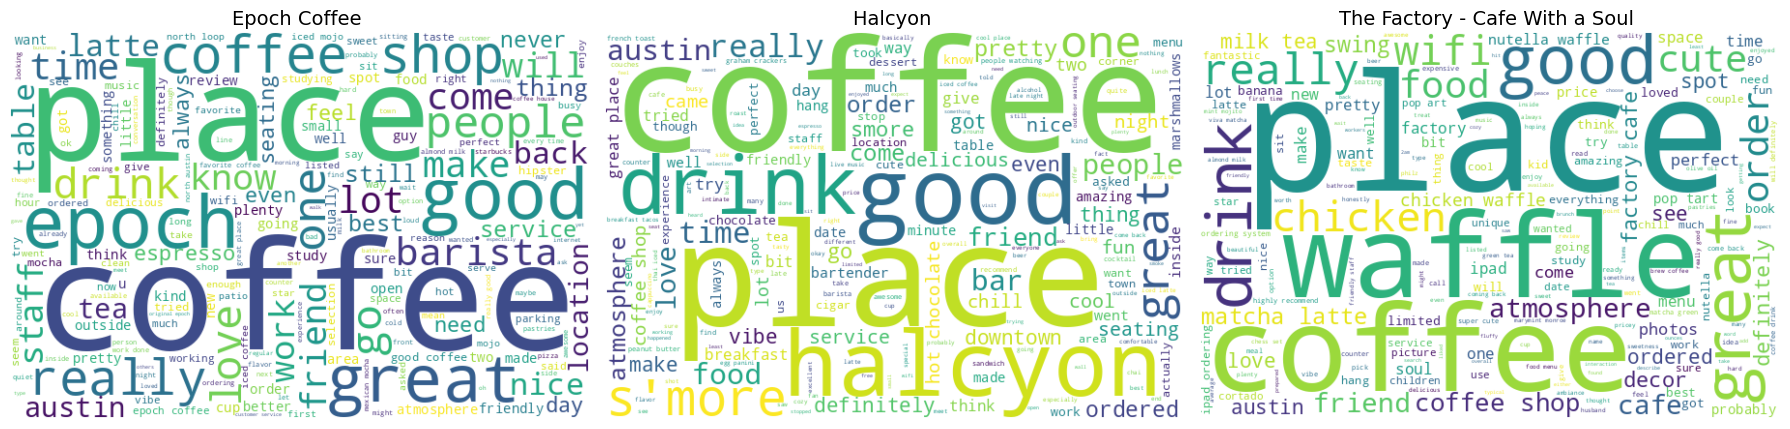

In [151]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

top3 = yelp["coffee_shop_name"].value_counts().nlargest(3).index.tolist()

plt.figure(figsize=(18, 6))
for i, shop in enumerate(top3):
    text = " ".join(
        yelp.loc[yelp["coffee_shop_name"] == shop, "review"]
    ).lower()
    wc = WordCloud(width=600, height=400, background_color="white").generate(text)
    ax = plt.subplot(1, 3, i + 1)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(shop, fontsize=14)
plt.tight_layout()
plt.show()

### Visualization #1 Word Clouds for Top 3 Coffee Shops
The trio of word clouds for Epoch Coffee, Halcyon, and The Factory – Cafe With a Soul highlights each shop’s unique customer-focused language. Epoch Coffee’s and Halcyon's cloud is dominated by “coffee,” “good,” and “place,” suggesting patrons praise its coffee, drinks, and the place as a whole. The Factory’s most prominent words—“coffee,” “place,” and “waffle”, similar to the first two but possibly highlighting their waffles a bit more. Viewing them side by side makes each café’s signature strengths immediately apparent.

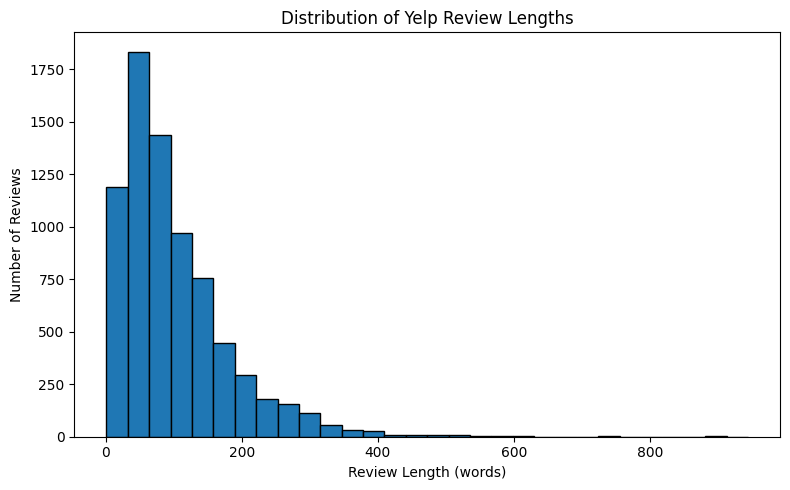

In [152]:
import matplotlib.pyplot as plt

yelp["length"] = yelp["review"].str.split().apply(len)

plt.figure(figsize=(8,5))
plt.hist(yelp["length"], bins=30, edgecolor='black')
plt.xlabel("Review Length (words)")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Yelp Review Lengths")
plt.tight_layout()
plt.show()

### Visualization #2 — Distribution of Yelp Review Lengths
The histogram of review lengths shows that most Yelp comments at these coffee shops fall between 20 and 60 words, with a peak around 30–40 words. A handful of very short reviews (under 10 words) and a long right‐hand tail of detailed posts (some exceeding 300 words) reveal that, while patrons generally keep feedback concise, a few take the time to write mini‐essays. This distribution aligns with our expectation of typical Yelp behavior—quick impressions punctuated by occasional deeper dives—and helps inform any preprocessing decisions like setting minimum word‐count thresholds or detecting outliers.

### Comparison Paragraph
The word clouds (Viz #1) and the length histogram (Viz #2) offer two distinct lenses on the same text data. Word clouds provide an immediate, qualitative snapshot of which terms dominate each shop’s reviews—ideal for theme‐spotting but lacking numeric precision. The histogram delivers that numeric rigor by showing exactly how verbose reviews are overall, yet it tells us nothing about what customers say. Together, they balance thematic exploration with structural insight, giving both a sense of what matters most to reviewers and how much they tend to write.